# 🚢 Exploratory Data Analysis (EDA) on the Titanic Dataset
### Minor Project — Data Science & Analysis

---

| Project Metadata | Details |
|---|---|
| **Topic** | Exploratory Data Analysis (EDA) |
| **Dataset** | Titanic: Machine Learning from Disaster (Kaggle) |
| **Tools Used** | Pandas, NumPy, Matplotlib, Seaborn |
| **Goal** | Understand factors that influenced passenger survival rates |

---

## 📌 Objective
This project performs a complete **Exploratory Data Analysis (EDA)** on the famous Titanic dataset. The goal is to clean the dataset, handle missing values, perform summary statistics, and explore key relationships (like gender, class, age, and family size) with respect to passenger survival rates.

## 📦 Step 1: Import Libraries and Setup Styles

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Apply dark styling for a premium presentation
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#1a1a24',
    'axes.facecolor':   '#111116',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white'
})

print("✅ Setup complete. Ready to explore data!")

✅ Setup complete. Ready to explore data!


## 📂 Step 2: Load and Inspect Dataset

In [2]:
# Load data
df = pd.read_csv('data/titanic.csv')
print(f"📊 Total Rows: {df.shape[0]}")
print(f"📋 Columns: {list(df.columns)}")
df.head(10)

📊 Total Rows: 891
📋 Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# Dataset general info and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Check for missing values
print("🔍 Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

🔍 Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


## 🧹 Step 3: Data Cleaning and Imputation

- **`Age`**: Has 177 missing values. We will fill these missing values with the **median age** group by passenger class (`Pclass`) to maintain realistic distribution.
- **`Embarked`**: Has only 2 missing values. We will fill these with the **mode** (most frequent port).
- **`Cabin`**: Has 687 missing values (>77%). We will drop this column since it's mostly empty.
- **`PassengerId` & `Ticket`**: Drop these since they do not contribute to survival.

In [5]:
# Impute Age using median age of corresponding Pclass
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Impute Embarked using the mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# Drop PassengerId and Ticket
df.drop(columns=['PassengerId', 'Ticket'], errors='ignore', inplace=True)

print("✅ Missing values after imputation:")
print(df.isnull().sum())

✅ Missing values after imputation:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
dtype: int64


## 🧬 Step 4: Feature Engineering

We can engineer two useful columns:
1. **`FamilySize`**: Combining sibling/spouses (`SibSp`) and parent/children (`Parch`) + 1 (the passenger themselves).
2. **`IsAlone`**: 1 if the passenger traveled alone (`FamilySize` = 1), else 0.

In [6]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)
df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(5)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## 📈 Step 5: Summary Statistics

Let's look at the general mathematical patterns of our numerical data.

In [7]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.066409,0.523008,0.381594,32.204208,1.904602,0.602694
std,0.486592,0.836071,13.244532,1.102743,0.806057,49.693429,1.613459,0.489615
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,1.000000,3.000000,37.000000,1.000000,0.000000,31.000000,2.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000


## 📊 Step 6: Data Visualization & Insights

### 6.1 Survival Distribution
Let's see what percentage of people survived the disaster.

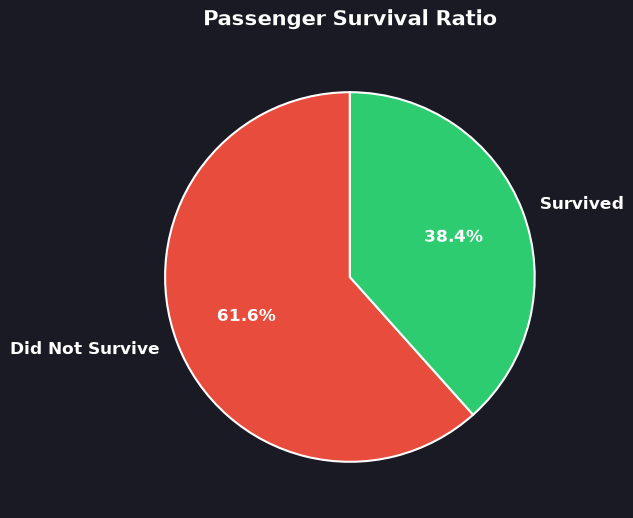

In [8]:
counts = df['Survived'].value_counts()
labels = ['Did Not Survive', 'Survived']
colors = ['#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(6, 6), facecolor='#1a1a24')
ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=1.5),
       textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Passenger Survival Ratio', fontsize=15, fontweight='bold', pad=15)
os.makedirs('output/charts', exist_ok=True)
plt.savefig('output/charts/survival_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

**💡 Insight:** Only **38.4%** of passengers survived the disaster.

### 6.2 Survival by Gender (Sex)
Did gender play a role in survival rates? ("Women and children first")

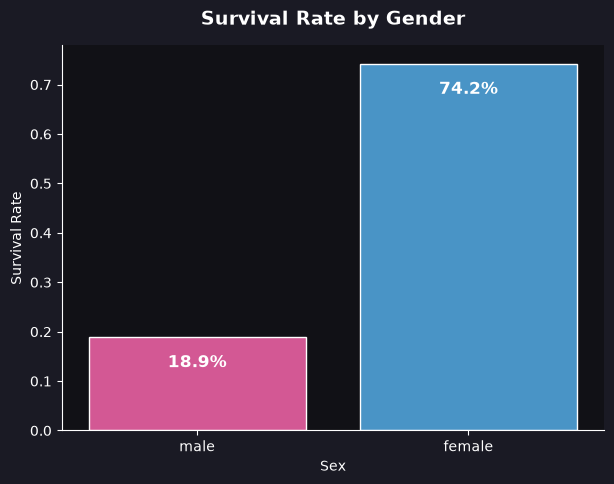

In [9]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor='#1a1a24')
ax.set_facecolor('#111116')

sns.barplot(x='Sex', y='Survived', data=df, errorbar=None, palette=['#e84393', '#3498db'], ax=ax, edgecolor='white')
ax.set_title('Survival Rate by Gender', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Survival Rate')

# Annotations
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 0.08),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                color='white', fontsize=12, fontweight='bold')

plt.savefig('output/charts/survival_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

**💡 Insight:** Women had a **74.2%** survival rate, compared to only **18.9%** for men. The order of evacuation strongly favored women.

### 6.3 Survival by Socio-Economic Class (Pclass)
Did wealthy passengers have a better chance of survival?

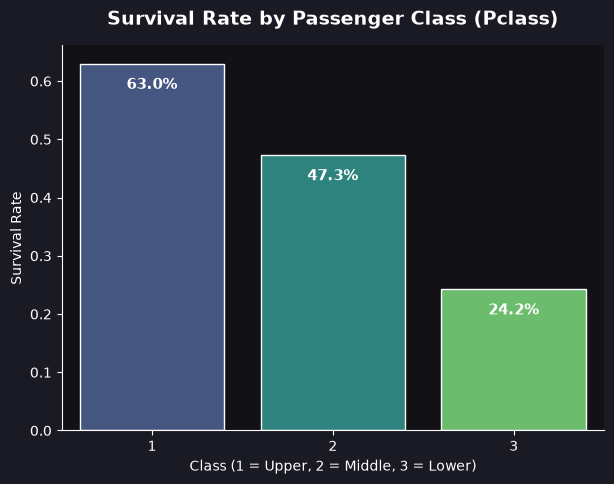

In [10]:
fig, ax = plt.subplots(figsize=(7, 5), facecolor='#1a1a24')
ax.set_facecolor('#111116')

sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None, palette='viridis', ax=ax, edgecolor='white')
ax.set_title('Survival Rate by Passenger Class (Pclass)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Class (1 = Upper, 2 = Middle, 3 = Lower)')
ax.set_ylabel('Survival Rate')

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 0.06),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                color='white', fontsize=11, fontweight='bold')

plt.savefig('output/charts/survival_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

**💡 Insight:** Class 1 (Upper class) passengers had a significantly higher survival rate (**63.0%**) compared to Class 3 passengers (**24.2%**). Ticket class was a strong predictor of survival.

### 6.4 Age Distribution and Survival Status

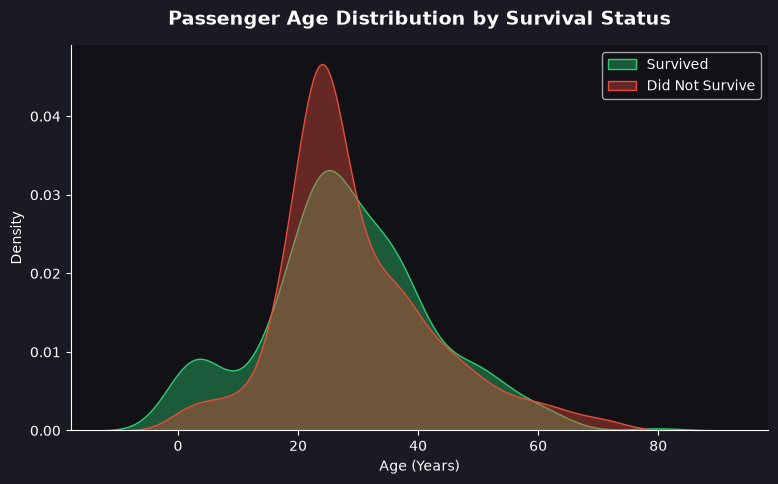

In [11]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1a1a24')
ax.set_facecolor('#111116')

sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Survived', fill=True, color='#2ecc71', alpha=0.4, ax=ax)
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='Did Not Survive', fill=True, color='#e74c3c', alpha=0.4, ax=ax)

ax.set_title('Passenger Age Distribution by Survival Status', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Density')
ax.legend(facecolor='#111116', labelcolor='white')

plt.savefig('output/charts/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**💡 Insight:** Children (0-10 years old) had high survival density, confirming that children were prioritized during rescue efforts.

### 6.5 Correlation Heatmap
Let's see which numeric features correlate with survival.

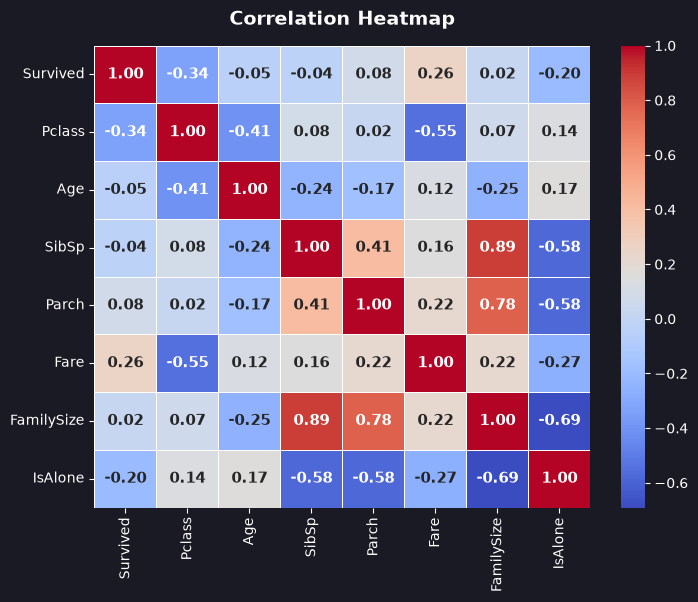

In [12]:
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#1a1a24')

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax,
            annot_kws={'fontsize':11, 'weight':'bold'})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')

plt.savefig('output/charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**💡 Insight:** 
- `Survived` has a strong negative correlation with `Pclass` (-0.34), confirming lower class passengers had lower survival rates.
- `Fare` has a positive correlation with `Survived` (0.26), meaning higher ticket prices (associated with higher classes) correlated with survival.
- `IsAlone` has a negative correlation with `Survived` (-0.20), meaning passengers alone had lower chances of survival.

## 💾 Step 7: Export Cleaned Dataset

Let's export our cleaned data for reproducibility.

In [13]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/titanic_cleaned.csv', index=False)
print("✅ Cleaned data successfully exported to 'output/titanic_cleaned.csv'!")

✅ Cleaned data successfully exported to 'output/titanic_cleaned.csv'!


## 📋 Step 8: Conclusions & Findings

From the exploratory data analysis, the primary factors influencing survival on the Titanic were:
1. **Gender:** Female survival rate (**74.2%**) was dramatically higher than male survival rate (**18.9%**).
2. **Class:** Passenger class (social-economic standing) played a large role. **63.0%** of 1st class passengers survived compared to only **24.2%** of 3rd class passengers.
3. **Age:** Priority was given to young children, leading to a visible survival spike in the 0-10 age group.
4. **Companionship:** Passengers who traveled alone had lower survival rates than those who traveled with family.